# Bahdanau 注意力

循环神经网络编码器将长度可变的序列转换为固定形状的上下文变量，
然后循环神经网络解码器根据生成的词元和上下文变量
按词元生成输出（目标）序列词元。
然而，即使并非所有输入（源）词元都对解码某个词元都有用，
在每个解码步骤中仍使用编码*相同*的上下文变量。
有什么方法能改变上下文变量呢？

受学习对齐想法的启发，Bahdanau等人提出了一个没有严格单向对齐限制的
可微注意力模型。
在预测词元时，如果不是所有输入词元都相关，模型将仅对齐（或参与）输入序列中与当前预测相关的部分。这是通过将上下文变量视为注意力集中的输出来实现的。

假设输入序列中有$T$个词元，
解码时间步$t'$的上下文变量是注意力集中的输出：

$$\mathbf{c}_{t'} = \sum_{t=1}^T \alpha(\mathbf{s}_{t' - 1}, \mathbf{h}_t) \mathbf{h}_t,$$

其中，时间步$t' - 1$时的解码器隐状态$\mathbf{s}_{t' - 1}$是查询，
编码器隐状态$\mathbf{h}_t$既是键，也是值，
注意力权重$\alpha$是使用

$$\alpha(\mathbf{q}, \mathbf{k}_i) = \mathrm{softmax}(a(\mathbf{q}, \mathbf{k}_i)) = \frac{\exp(a(\mathbf{q}, \mathbf{k}_i))}{\sum_{j=1}^m \exp(a(\mathbf{q}, \mathbf{k}_j))} \in \mathbb{R}.$$

所定义的加性注意力打分函数计算的。

下图描述了Bahdanau注意力的架构。

![一个带有Bahdanau注意力的循环神经网络编码器-解码器模型](img/Bahdanau-img.svg)


In [1]:
import torch
from torch import nn
from d2l import torch as d2l

## 定义注意力解码器

下面看看如何定义Bahdanau注意力，实现循环神经网络编码器-解码器。
其实，我们只需重新定义解码器即可。
为了更方便地显示学习的注意力权重，
以下`AttentionDecoder`类定义了[**带有注意力机制解码器的基本接口**]。

In [2]:
#@save
class AttentionDecoder(d2l.Decoder):
    """带有注意力机制解码器的基本接口"""
    # 接收任意参数 **kwargs
    def __init__(self, **kwargs):  
        super(AttentionDecoder, self).__init__(**kwargs)

    @property  # 装饰器：把方法变成「属性」，调用不用加括号
    # 普通方法：obj.attention_weights()
    # 加装饰器后：obj.attention_weights（不用括号，像调用变量一样）
    def attention_weights(self):  # 定义注意力权重属性
        # 强制所有继承这个类的子类，必须自己实现 attention_weights 方法如果不实现，运行就会直接报错。
        raise NotImplementedError  # 强制子类必须重写这个方法
        
# 总结
# 这是带注意力解码器的接口类，定义统一规范
# 子类必须实现 attention_weights 属性
# 作用：获取注意力权重（用于可视化、调试、分析）
# 本身不能直接用，是给其他解码器当「父类」的模板

接下来，让我们在接下来的`Seq2SeqAttentionDecoder`类中
[**实现带有Bahdanau注意力的循环神经网络解码器**]。
首先，初始化解码器的状态，需要下面的输入：

1. 编码器在所有时间步的最终层隐状态，将作为注意力的键和值；
1. 上一时间步的编码器全层隐状态，将作为初始化解码器的隐状态；
1. 编码器有效长度（排除在注意力池中填充词元）。

在每个解码时间步骤中，解码器上一个时间步的最终层隐状态将用作查询。
因此，注意力输出和输入嵌入都连结为循环神经网络解码器的输入。

In [3]:
class Seq2SeqAttentionDecoder(AttentionDecoder):  # 继承刚才的注意力解码器接口
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super(Seq2SeqAttentionDecoder, self).__init__(**kwargs)
        
        # 加性注意力层（计算注意力权重用）
        self.attention = d2l.AdditiveAttention(
            num_hiddens, num_hiddens, num_hiddens, dropout)
        
        # 词嵌入层：把单词编号 → 向量
        self.embedding = nn.Embedding(vocab_size, embed_size)
        
        # RNN 使用 GRU，输入是【词嵌入 + 注意力上下文】拼接后的向量
        self.rnn = nn.GRU(
            embed_size + num_hiddens, num_hiddens, num_layers,
            dropout=dropout)
        
        # 全连接层：把 RNN 输出 → 词典概率
        self.dense = nn.Linear(num_hiddens, vocab_size)
        
        # 定义注意力、词嵌入、GRU、全连接层;4个核心组件

    # 初始化解码器状态
    def init_state(self, enc_outputs, enc_valid_lens, *args):  # 接收编码器的输出
        # outputs的形状为(batch_size，num_steps，num_hiddens).
        # hidden_state的形状为(num_layers，batch_size，num_hiddens)
        # 调整形状方便后续计算
        outputs, hidden_state = enc_outputs
        
        # 返回三个东西：
        # 编码器所有时刻输出（用来做注意力）
        # 编码器最后隐状态（解码器初始隐状态）
        # 有效长度（忽略 padding）
        return (outputs.permute(1, 0, 2), hidden_state, enc_valid_lens)

    # 前向传播 forward
    def forward(self, X, state):
        # enc_outputs的形状为(batch_size,num_steps,num_hiddens).
        # hidden_state的形状为(num_layers,batch_size,num_hiddens)
        enc_outputs, hidden_state, enc_valid_lens = state
        
        # 把输入 X 转成词嵌入，并调整形状：(num_steps, batch_size, embed_size)
        X = self.embedding(X).permute(1, 0, 2)
        
        # 存每一步输出;注意力权重
        outputs, self._attention_weights = [], []
        
        # 逐 词 生成（一步一步解码）
        for x in X:
            # 用解码器最后一层隐状态作为 Query
            # query的形状为(batch_size,1,num_hiddens)
            # 代表：我现在要翻译下一个词，我该关注输入句子的哪里？
            query = torch.unsqueeze(hidden_state[-1], dim=1)
            
            # 计算注意力，得到上下文向量
            # context的形状为(batch_size,1,num_hiddens)
            # 作用：根据当前解码器状态，自动聚焦输入序列最相关的位置
            context = self.attention(
                query, enc_outputs, enc_outputs, enc_valid_lens)
            
            # 把【上下文向量】和【当前词嵌入】拼接
            # 在特征维度上连结
            # 每一步输入 = 单词信息 + 注意力聚焦的上下文
            x = torch.cat((context, torch.unsqueeze(x, dim=1)), dim=-1)
            
            # 送入 GRU
            # 将x变形为(1,batch_size,embed_size+num_hiddens)
            out, hidden_state = self.rnn(x.permute(1, 0, 2), hidden_state)
            outputs.append(out)
            self._attention_weights.append(self.attention.attention_weights)
            
        # 最后经过全连接层，输出词典概率
        # 全连接层变换后，outputs的形状为(num_steps,batch_size,vocab_size)
        outputs = self.dense(torch.cat(outputs, dim=0))
        return outputs.permute(1, 0, 2), [enc_outputs, hidden_state,
                                          enc_valid_lens]

    # 暴露注意力权重;方便画图看注意力热图
    @property
    def attention_weights(self):
        return self._attention_weights

接下来，使用包含7个时间步的4个序列输入的小批量[**测试Bahdanau注意力解码器**]。

验证带注意力的 Seq2Seq 模型是否能正常前向传播，检查所有张量形状是否正确。

造一个假数据 X
过一遍编码器 → 解码器
打印输出形状，确认维度没有报错、符合预期

In [4]:
# 创建编码器：Seq2Seq的编码器
encoder = d2l.Seq2SeqEncoder(vocab_size=10, # 词典大小：10个词
                             embed_size=8,  # 词向量维度：8
                             num_hiddens=16,# 隐藏层维度：16
                             num_layers=2)  # 2层GRU
encoder.eval()  # 测试模式（不启用dropout）

# 创建带注意力解码器
decoder = Seq2SeqAttentionDecoder(vocab_size=10, embed_size=8, num_hiddens=16,num_layers=2)
decoder.eval()

# 构造假输入：4个样本，每个样本长度7
X = torch.zeros((4, 7), dtype=torch.long)  # shape:(batch_size,num_steps)
# 初始化解码器状态（编码器输出 → 解码器初始状态）
state = decoder.init_state(encoder(X), None)
output, state = decoder(X, state)  # 解码器前向传播
# 打印所有形状，检查是否正确
output.shape, len(state), state[0].shape, len(state[1]), state[1][0].shape

(torch.Size([4, 7, 10]), 3, torch.Size([4, 7, 16]), 2, torch.Size([4, 16]))

## [**训练**]

我们在这里指定超参数，实例化一个带有Bahdanau注意力的编码器和解码器，
并对这个模型进行机器翻译训练。
由于新增的注意力机制，训练要慢得多。

loss 0.019, 13134.8 tokens/sec on cpu


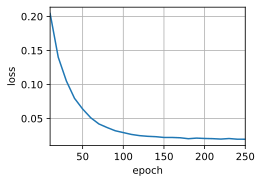

In [5]:
# 词向量维度 32
# GRU 隐藏层维度 32
# 2 层 GRU
# 防止过拟合
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10  # 一次训练 64 句; 句子最大长度 10
lr, num_epochs, device = 0.005, 250, d2l.try_gpu()

# 加载翻译数据集
# 机器翻译数据集（英语 → 法语）
# src_vocab：源语言（英语）词典
# tgt_vocab：目标语言（法语）词典
# train_iter：分批加载数据
train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)

# 编码器
encoder = d2l.Seq2SeqEncoder(
    len(src_vocab), embed_size, num_hiddens, num_layers, dropout)

# 解码器
decoder = Seq2SeqAttentionDecoder(
    len(tgt_vocab), embed_size, num_hiddens, num_layers, dropout)

# 把编码器和解码器绑在一起，变成完整的翻译模型。
net = d2l.EncoderDecoder(encoder, decoder)

# 训练函数; 专门用来训练 Seq2Seq 模型。
d2l.train_seq2seq(net,train_iter,lr, num_epochs, tgt_vocab, device)

模型训练后，我们用它[**将几个英语句子翻译成法语**]并计算它们的BLEU分数。

In [6]:
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']

for eng, fra in zip(engs, fras):
    # # 核心：调用预测函数 → 得到翻译结果 + 注意力权重
    translation, dec_attention_weight_seq = d2l.predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device, True)# True:是否返回注意力权重
    
    # 打印：英文 → 翻译结果 + BLEU 分数
    print(f'{eng} => {translation}, ',
          f'bleu {d2l.bleu(translation, fra, k=2):.3f}')

go . => va !,  bleu 1.000
i lost . => j'ai perdu .,  bleu 1.000
he's calm . => il est malade .,  bleu 0.658
i'm home . => je suis chez moi .,  bleu 1.000


```
dec_attention_weight_seq = [
   第1个输出词的注意力,
   第2个输出词的注意力,
   第3个输出词的注意力,
   ...
]
```

每一个注意力的形状是：

```
(1, 1, 输出词位置, 输入词长度)
```

step = 每一步的注意力; 
step[0] → 取第 1 个批量; 
step[0][0] → 取第 1 个注意力头; 
step[0][0][0] → 取第 1 行真正的权重向量

把每一步的注意力按行拼接，变成一个二维矩阵：
[输出词数 × 输入词数]

重塑形状
reshape((1, 1, -1, num_steps))

最终变成：
(1, 1, 输出词数, 输入词数)

In [7]:
# 从一堆复杂的注意力数据里，把真正有用的权重抽出来，整理成热图需要的形状！
attention_weights = torch.cat([step[0][0][0] for step in dec_attention_weight_seq], 0).reshape((
    1, 1, -1, num_steps))

训练结束后，下面通过[**可视化注意力权重**]
会发现，每个查询都会在键值对上分配不同的权重，这说明
在每个解码步中，输入序列的不同部分被选择性地聚集在注意力池中。

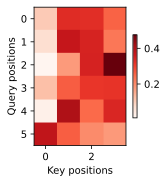

In [8]:
# 加上一个包含序列结束词元
d2l.show_heatmaps(
    attention_weights[:, :, :, :len(engs[-1].split()) + 1].cpu(),# 张量从 GPU 移到 CPU；
    xlabel='Key positions', ylabel='Query positions')

## 小结

* 在预测词元时，如果不是所有输入词元都是相关的，那么具有Bahdanau注意力的循环神经网络编码器-解码器会有选择地统计输入序列的不同部分。这是通过将上下文变量视为加性注意力池化的输出来实现的。
* 在循环神经网络编码器-解码器中，Bahdanau注意力将上一时间步的解码器隐状态视为查询，在所有时间步的编码器隐状态同时视为键和值。

## 练习

1. 在实验中用LSTM替换GRU。
1. 修改实验以将加性注意力打分函数替换为缩放点积注意力，它如何影响训练效率？